#Import Libraries

In [ ]:
# Data Processing
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


#Data Loading and Overview

In [ ]:
# Load the dataset
Traffic_Accident = pd.read_csv('/content/Traffic_Accident.csv')

# Display the first five rows of the dataset
Traffic_Accident.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,1.0


In [ ]:
# Basic Information
Traffic_Accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               782 non-null    object 
 1   Road_Type             784 non-null    object 
 2   Time_of_Day           783 non-null    object 
 3   Traffic_Density       783 non-null    float64
 4   Speed_Limit           784 non-null    float64
 5   Number_of_Vehicles    783 non-null    float64
 6   Driver_Alcohol        781 non-null    float64
 7   Accident_Severity     781 non-null    object 
 8   Road_Condition        782 non-null    object 
 9   Vehicle_Type          784 non-null    object 
 10  Driver_Age            782 non-null    float64
 11  Driver_Experience     782 non-null    float64
 12  Road_Light_Condition  781 non-null    object 
 13  Accident              775 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.3+ KB


In [ ]:
# Summary Statistics
Traffic_Accident.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,783.000000,784.000000,783.000000,781.000000,782.000000,782.000000,775.000000
mean,1.014049,71.547194,3.268199,0.160051,43.498721,39.195652,0.307097
std,0.780882,31.975890,2.010738,0.366889,15.247237,15.343488,0.461588
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,57.000000,53.000000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


In [ ]:
# Number of rows and columns
Traffic_Accident.shape

(843, 14)

#Data Preprocessing

##Remove duplicate

In [ ]:
# Counts the number of duplicate rows
Traffic_Accident.duplicated().sum()

53

In [ ]:
# Removes duplicate rows
Traffic_Accident = Traffic_Accident.drop_duplicates()

Traffic_Accident.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,1.0


##Handle missing values

In [ ]:
#The count of missing values (NaN) in each column
Traffic_Accident.isnull().sum()

,0
Weather,44
Road_Type,42
Time_of_Day,42
Traffic_Density,42
Speed_Limit,42
Number_of_Vehicles,42
Driver_Alcohol,43
Accident_Severity,43
Road_Condition,43
Vehicle_Type,42


In [ ]:
# Remove rows (or columns) that contain missing values (NaN)
Traffic_Accident.dropna(inplace=True)

Traffic_Accident.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Truck,27.0,26.0,Daylight,1.0
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Car,29.0,22.0,Artificial Light,1.0
18,Foggy,City Road,Night,1.0,60.0,3.0,0.0,Moderate,Wet,Motorcycle,35.0,32.0,No Light,0.0


In [ ]:
Traffic_Accident.isnull().sum()

,0
Weather,0
Road_Type,0
Time_of_Day,0
Traffic_Density,0
Speed_Limit,0
Number_of_Vehicles,0
Driver_Alcohol,0
Accident_Severity,0
Road_Condition,0
Vehicle_Type,0


#Exploratory Data Analysis

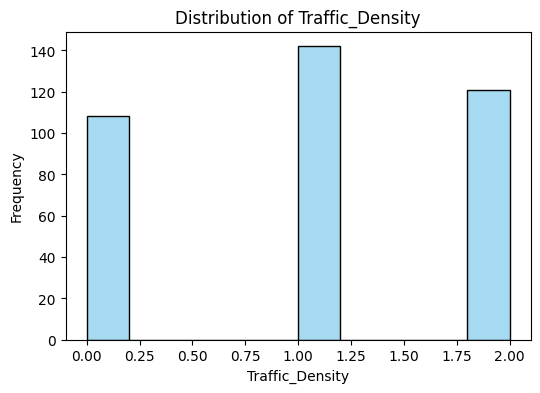

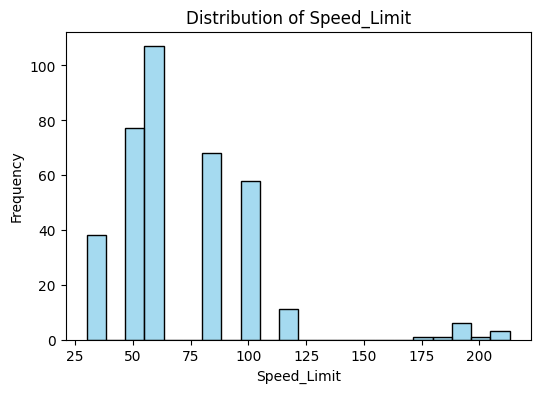

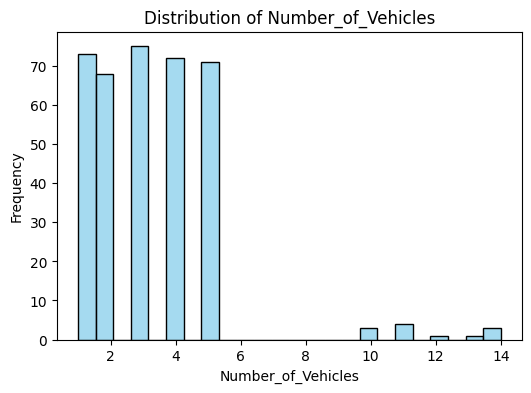

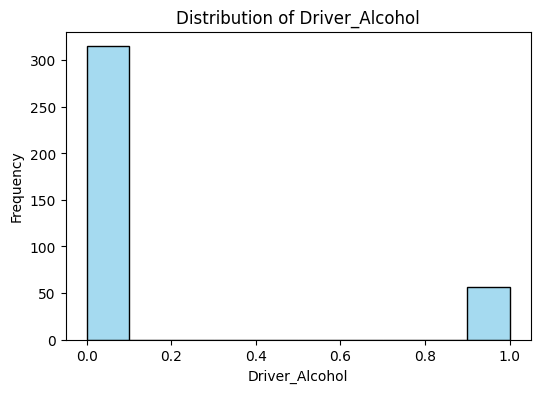

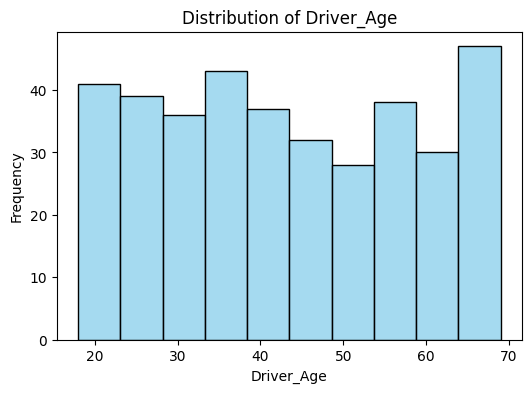

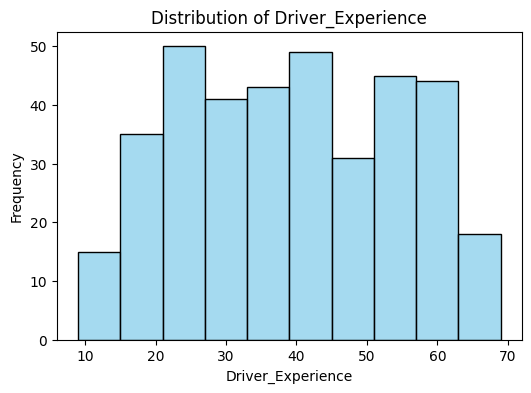

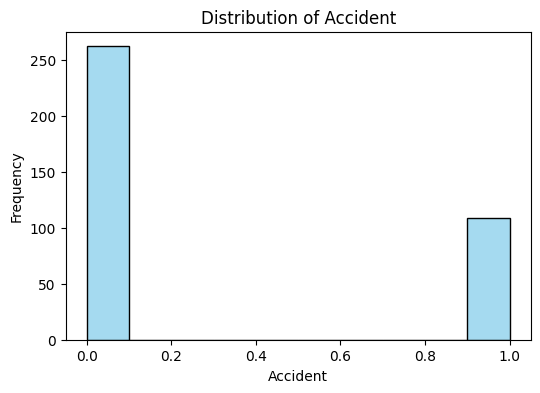

In [ ]:
# Extract numerical features based on column data type
numerical_features = Traffic_Accident.select_dtypes(include=['float64', 'int64']).columns.tolist()


# Histograms for numerical features
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(Traffic_Accident[feature], color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

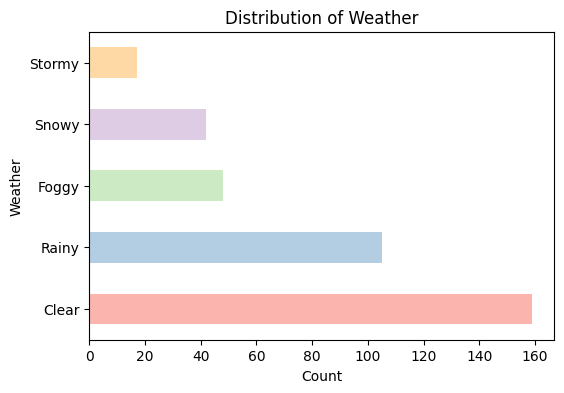

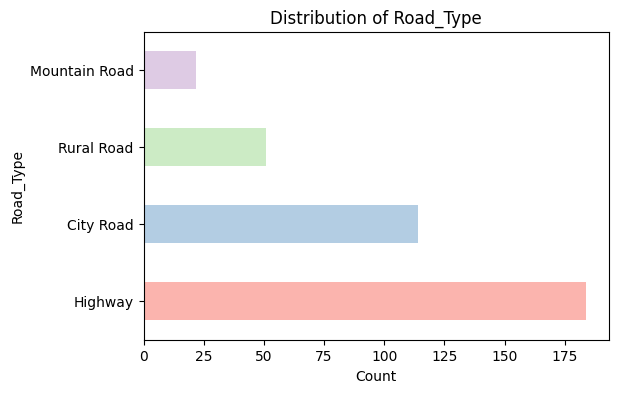

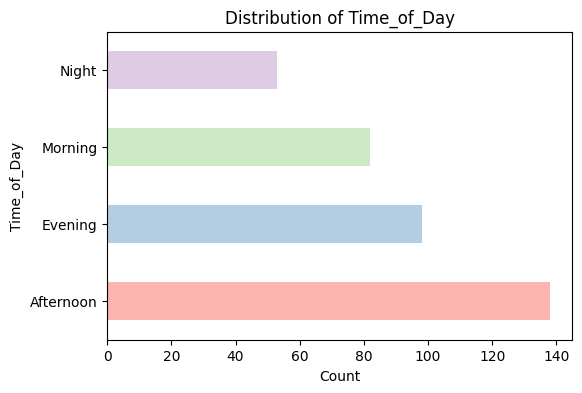

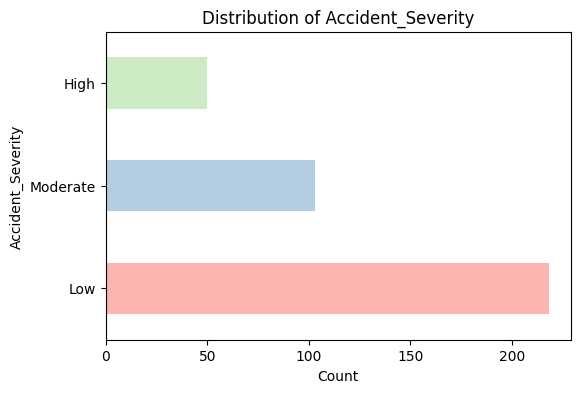

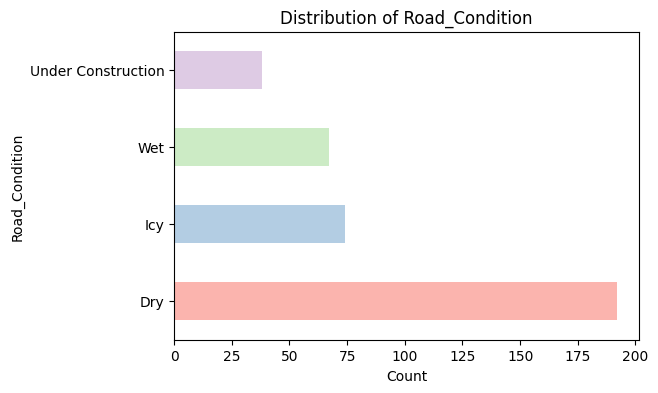

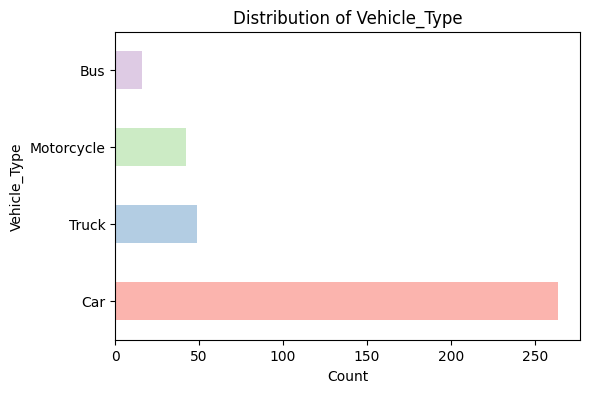

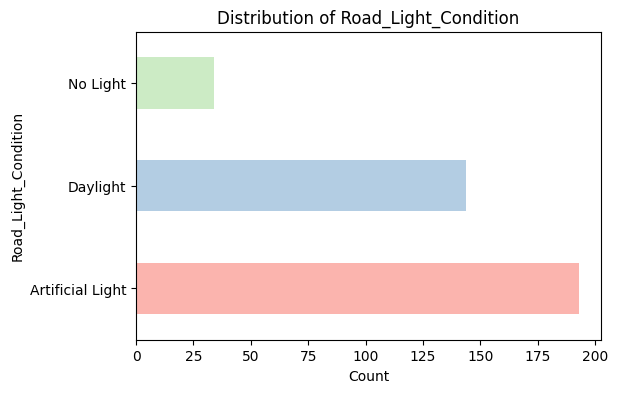

In [ ]:
# Extract Categorical features based on column data type
categorical_features = Traffic_Accident.select_dtypes(include="object").columns

# Bar plots for categorical features
for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    Traffic_Accident[feature].value_counts().plot(kind='barh', color=sns.color_palette('Pastel1', n_colors=10))
    plt.title(f'Distribution of {feature}')
    plt.ylabel(feature)
    plt.xlabel('Count')
    plt.show()

##Outliers:

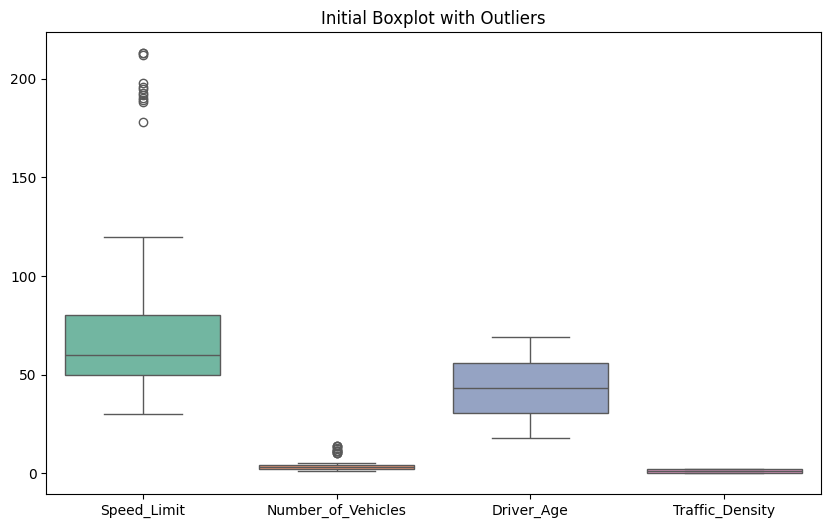

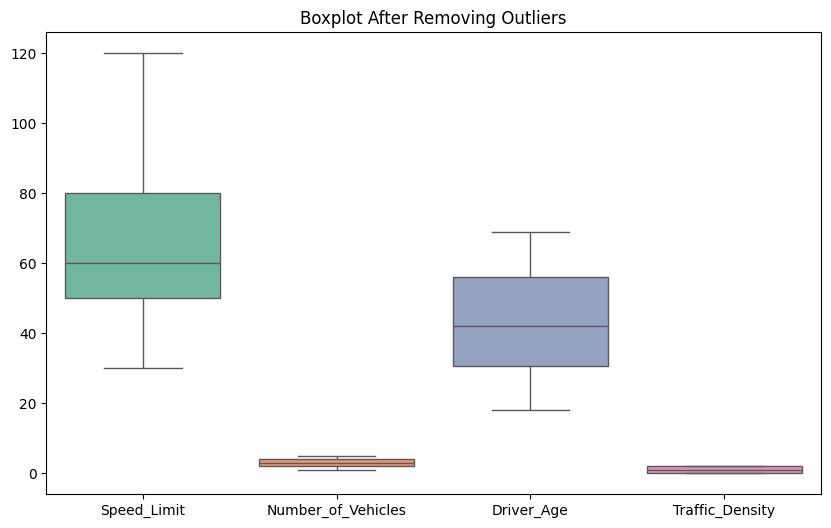

In [ ]:
# Step 1: Plot the initial boxplot to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=Traffic_Accident[['Speed_Limit', 'Number_of_Vehicles', 'Driver_Age', 'Traffic_Density']], palette="Set2")
plt.title('Initial Boxplot with Outliers')
plt.show()


# Step 2: Remove outliers using the IQR method
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)  # First quartile
    Q3 = data[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1                     # Interquartile range
    lower_bound = Q1 - 1.5 * IQR      # Lower bound
    upper_bound = Q3 + 1.5 * IQR      # Upper bound
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]


# Apply outlier removal to relevant numerical columns
columns_with_outliers = ['Speed_Limit', 'Number_of_Vehicles', 'Driver_Age', 'Traffic_Density']
for col in columns_with_outliers:
    Traffic_Accident = remove_outliers(Traffic_Accident, col)


# Step 3: Plot the boxplot after removing outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=Traffic_Accident[['Speed_Limit', 'Number_of_Vehicles', 'Driver_Age', 'Traffic_Density']], palette="Set2")
plt.title('Boxplot After Removing Outliers')
plt.show()

In [ ]:
# Calculate central tendencies and spread manually for numerical features
central_tendencies_spread = pd.DataFrame(index=numerical_features)

# Calculate mean (average) for each numerical feature
central_tendencies_spread['mean'] = Traffic_Accident[numerical_features].mean()

# Calculate median for each numerical feature
central_tendencies_spread['median'] = Traffic_Accident[numerical_features].median()

# Calculate mode for each numerical feature (mode can have multiple values, so we pick the first one)
central_tendencies_spread['mode'] = Traffic_Accident[numerical_features].mode().iloc[0]

# Calculate variance for each numerical feature
central_tendencies_spread['variance'] = Traffic_Accident[numerical_features].var()

# Calculate standard deviation for each numerical feature
central_tendencies_spread['std_dev'] = Traffic_Accident[numerical_features].std()

# Print the results
print(central_tendencies_spread)


                         mean  median  mode    variance    std_dev
Traffic_Density      1.041783     1.0   1.0    0.621154   0.788133
Speed_Limit         66.768802    60.0  60.0  516.904499  22.735534
Number_of_Vehicles   3.000000     3.0   3.0    2.000000   1.414214
Driver_Alcohol       0.150418     0.0   0.0    0.128149   0.357979
Driver_Age          43.150418    42.0  27.0  224.022004  14.967365
Driver_Experience   38.635097    39.0  26.0  230.941893  15.196772
Accident             0.289694     0.0   0.0    0.206346   0.454253


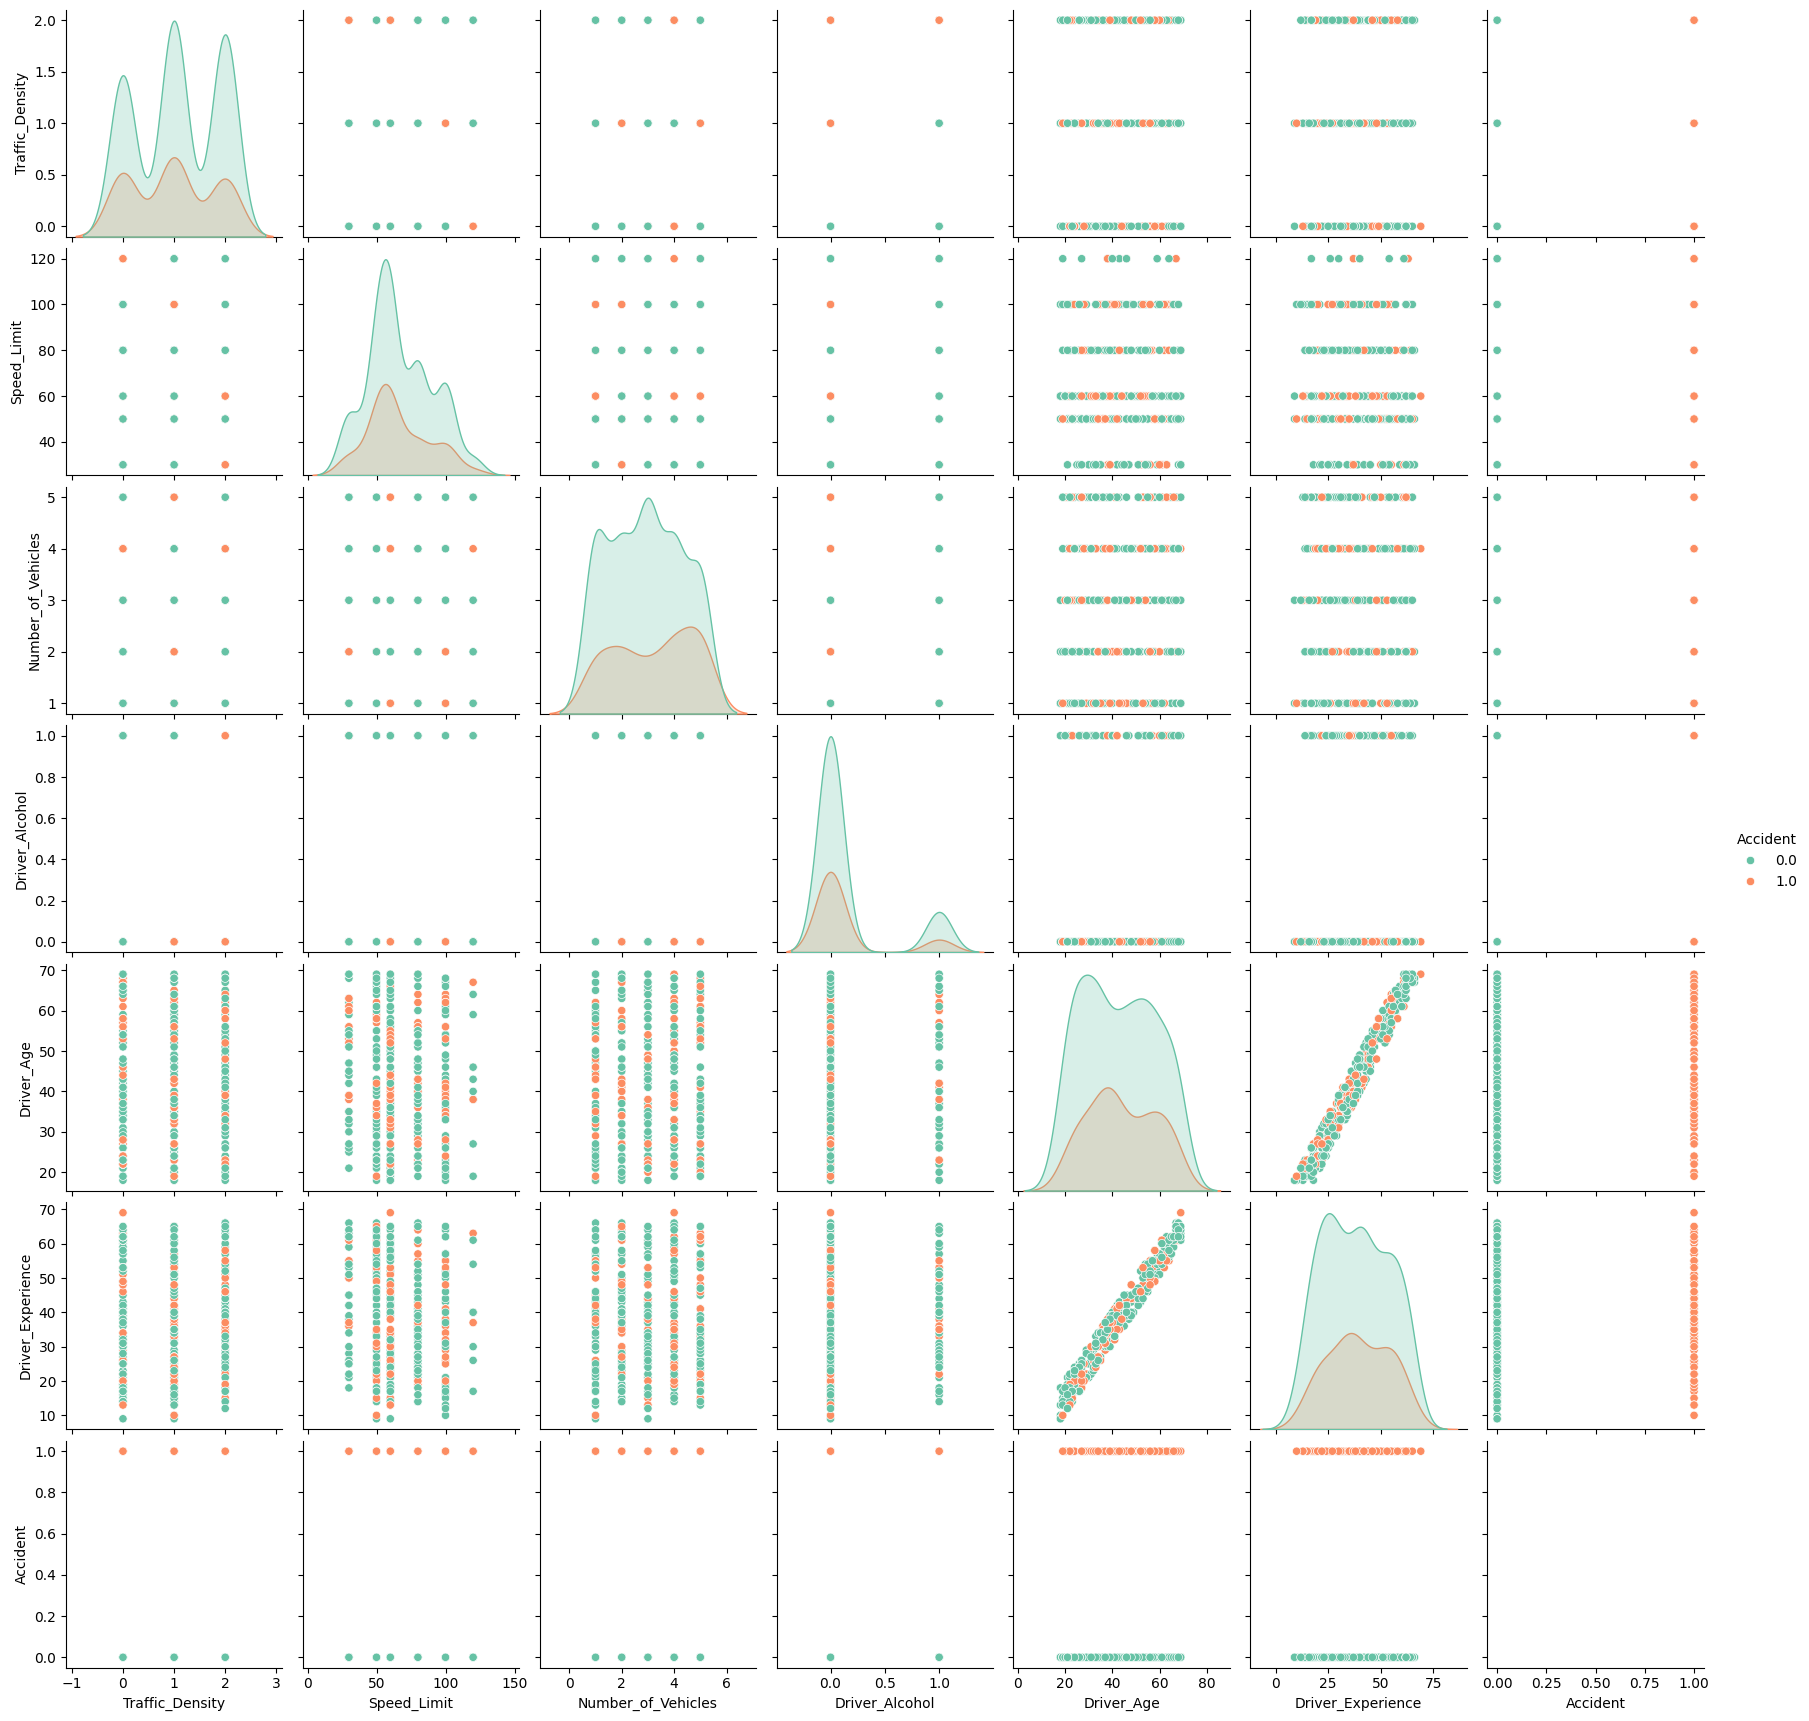

In [ ]:
# Pair plot for the numerical features with the target feature 'Accident'
sns.pairplot(Traffic_Accident, vars=numerical_features, hue='Accident', palette="Set2")
plt.show()

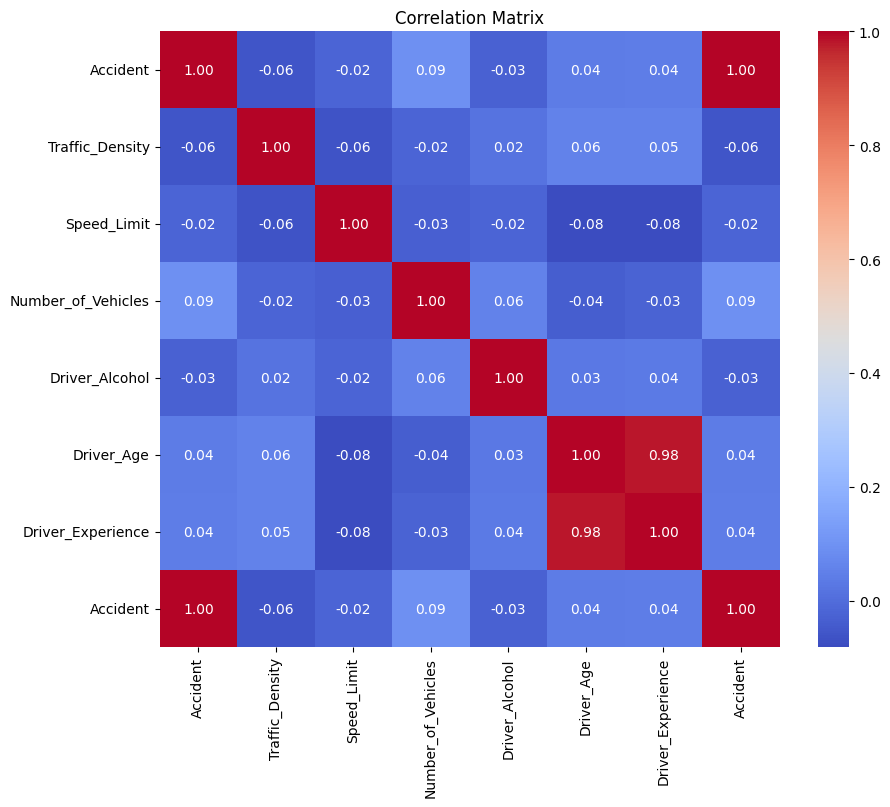

In [ ]:
# Correlation heatmap for numeric features with the target feature 'Accident'
correlation_matrix = Traffic_Accident[['Accident'] + numerical_features].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Melt the correlation matrix into a long format
correlation_matrix_melted = correlation_matrix.reset_index().melt(id_vars="index")

# Remove self-correlation (correlation with itself)
correlation_matrix_melted = correlation_matrix_melted[correlation_matrix_melted["index"] != correlation_matrix_melted["variable"]]

# Filter the strong correlations (greater than 0.8 or less than -0.8)
strong_correlations = correlation_matrix_melted[abs(correlation_matrix_melted["value"]) > 0.8]

# Print the strong correlations
for _, row in strong_correlations.iterrows():
    print(f"The correlation between {row['index']} and {row['variable']} is: {row['value']:.2f}")


The correlation between Driver_Experience and Driver_Age is: 0.98
The correlation between Driver_Age and Driver_Experience is: 0.98


##Feature Engineering

In [ ]:
# Create 'Age_vs_Experience' to explore the difference between Driver's Age and Experience.
Traffic_Accident['Age_vs_Experience'] = Traffic_Accident['Driver_Age'] - Traffic_Accident['Driver_Experience']
Traffic_Accident = Traffic_Accident.drop(['Driver_Age', 'Driver_Experience'], axis = 1)

Traffic_Accident.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Road_Light_Condition,Accident,Age_vs_Experience
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,Artificial Light,0.0,2.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,Daylight,0.0,3.0
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Truck,Daylight,1.0,1.0
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Car,Artificial Light,1.0,7.0
18,Foggy,City Road,Night,1.0,60.0,3.0,0.0,Moderate,Wet,Motorcycle,No Light,0.0,3.0


In [ ]:
# One-Hot Encoding: Converts categorical variables into separate binary columns, suitable for unordered categories.
# convert the categorical variable city and rain into a set of binary (one-hot)
Traffic_Accident_encoded = pd.get_dummies(Traffic_Accident, columns= ['Weather', 'Road_Type', 'Time_of_Day','Road_Condition','Vehicle_Type', 'Road_Light_Condition'], dtype = int)


# Label Encoding: Converts categorical variables into integer values, suitable for ordered categories.
label_encoder = LabelEncoder()
Traffic_Accident_encoded[ 'Accident_Severity'] = label_encoder.fit_transform(Traffic_Accident[ 'Accident_Severity'])

Traffic_Accident_encoded.head()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Accident,Age_vs_Experience,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Stormy,Road_Type_City Road,Road_Type_Highway,Road_Type_Mountain Road,Road_Type_Rural Road,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Road_Condition_Dry,Road_Condition_Icy,Road_Condition_Under Construction,Road_Condition_Wet,Vehicle_Type_Bus,Vehicle_Type_Car,Vehicle_Type_Motorcycle,Vehicle_Type_Truck,Road_Light_Condition_Artificial Light,Road_Light_Condition_Daylight,Road_Light_Condition_No Light
2,1.0,60.0,4.0,0.0,1,0.0,2.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0
3,2.0,60.0,3.0,0.0,1,0.0,3.0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0
6,0.0,60.0,4.0,0.0,1,1.0,1.0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0
7,0.0,60.0,4.0,0.0,1,1.0,7.0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0
18,1.0,60.0,3.0,0.0,2,0.0,3.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1


#Model Building and Evaluation

In [ ]:
# Separate features and target variable
X = Traffic_Accident_encoded.drop('Accident', axis=1)
y = Traffic_Accident_encoded['Accident']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:")
print(class_report)


Model Accuracy: 0.6944444444444444

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.94      0.81        51
         1.0       0.40      0.10      0.15        21

    accuracy                           0.69        72
   macro avg       0.56      0.52      0.48        72
weighted avg       0.62      0.69      0.62        72



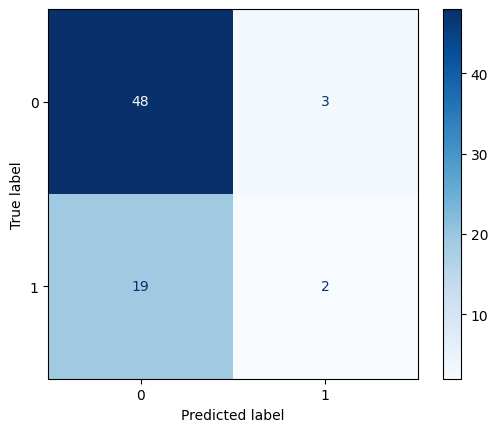

In [ ]:
# Visualize the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap='Blues');

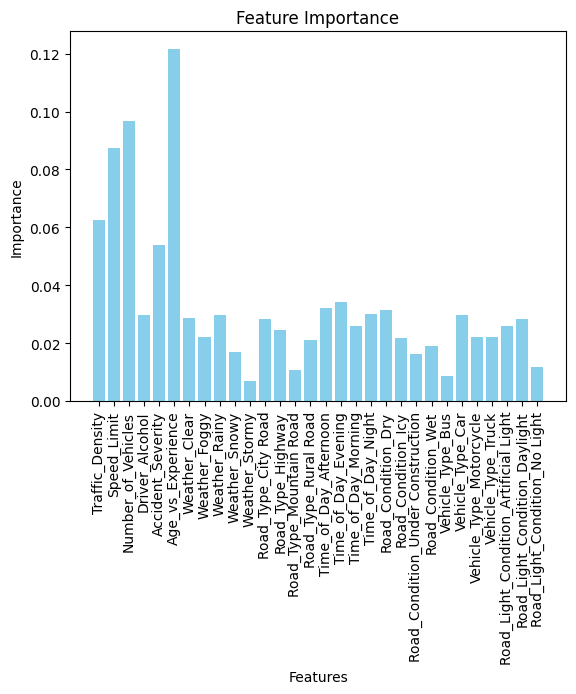

In [ ]:
# Visualization of Feature Importance
feature_importances = model.feature_importances_
plt.bar(X.columns, feature_importances, color = 'skyblue')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()